<a href="https://colab.research.google.com/github/monasolgi/Computer_vision/blob/main/Fully_connectedNN_VS_CNN_Bart_homer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
#libraries
import tensorflow as tf
import tensorflow_datasets as tfds
import tensorflow_hub as hub
import os
import random
import shutil
import matplotlib.pyplot as plt

#Upload zip file with image data.
#Existing zip files are cleared first to avoid file name clashes
from google.colab import files
!rm /content/*.zip
uploaded = files.upload()

rm: cannot remove '/content/*.zip': No such file or directory


Saving homer_bart_1.zip to homer_bart_1.zip


In [28]:
!rm -rf /content/homer_bart_1
!rm -rf /content/__MACOSX

!unzip -o /content/homer_bart_1.zip -d /content/

Archive:  /content/homer_bart_1.zip
   creating: /content/homer_bart_1/
  inflating: /content/homer_bart_1/homer38.bmp  
  inflating: /content/homer_bart_1/bart58.bmp  
  inflating: /content/homer_bart_1/bart70.bmp  
  inflating: /content/homer_bart_1/homer10.bmp  
  inflating: /content/homer_bart_1/bart64.bmp  
  inflating: /content/homer_bart_1/homer119.bmp  
  inflating: /content/homer_bart_1/bart162.bmp  
  inflating: /content/homer_bart_1/homer124.bmp  
  inflating: /content/homer_bart_1/bart65.bmp  
  inflating: /content/homer_bart_1/bart71.bmp  
  inflating: /content/homer_bart_1/bart59.bmp  
  inflating: /content/homer_bart_1/bart67.bmp  
  inflating: /content/homer_bart_1/homer13.bmp  
  inflating: /content/homer_bart_1/bart73.bmp  
  inflating: /content/homer_bart_1/bart98.bmp  
  inflating: /content/homer_bart_1/bart161.bmp  
  inflating: /content/homer_bart_1/bart149.bmp  
  inflating: /content/homer_bart_1/bart148.bmp  
  inflating: /content/homer_bart_1/bart160.bmp  
  in

**Load Dataset**

# **2. Check files**

In [30]:
import os
base_path='/content/homer_bart_1'
files=os.listdir(base_path)
print("Number of images:",len(files))
print(files[:5])


Number of images: 270
['homer58.bmp', 'homer82.bmp', 'bart66.bmp', 'homer55.bmp', 'bart126.bmp']


# **3. Show some images**

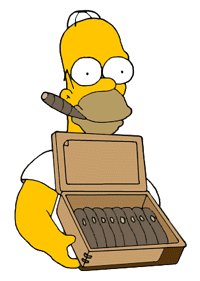

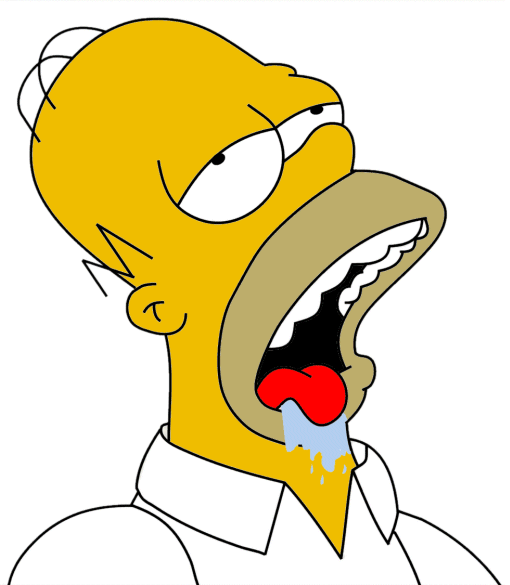

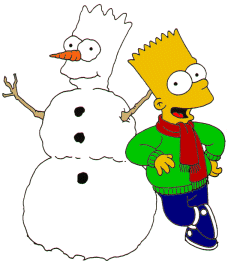

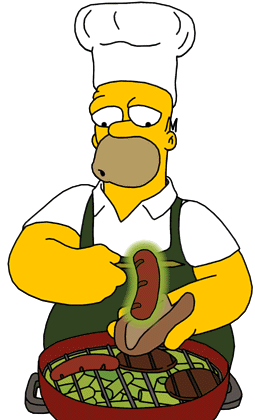

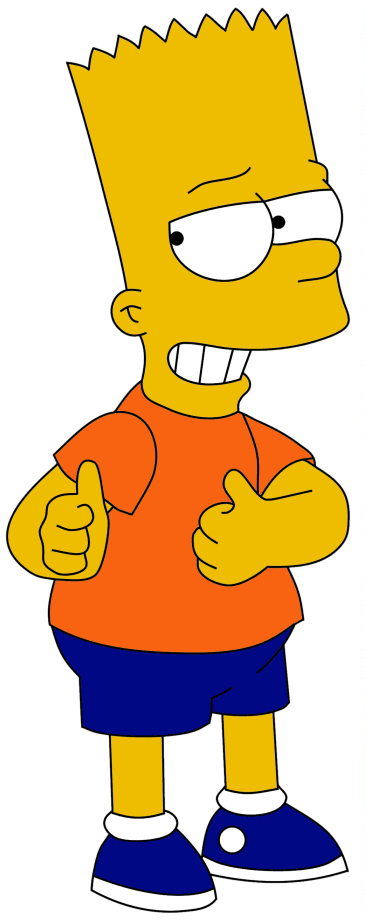

In [31]:
import cv2
from google.colab.patches import cv2_imshow
for i in range(5):
  img=cv2.imread(base_path+'/'+files[i])
  cv2_imshow(img)


**Step 4 — Check image sizes**

In [32]:
sizes=[]

for file in files:
  img=cv2.imread(base_path+'/'+file)
  if img is not None:
    sizes.append(img.shape)
print("Example sizes:", sizes[:5])
print("Unique sizes:", set(sizes))
print("Number of unique sizes:", len((set(sizes))))

Example sizes: [(281, 200, 3), (585, 510, 3), (264, 234, 3), (420, 255, 3), (920, 365, 3)]
Unique sizes: {(320, 268, 3), (284, 164, 3), (330, 400, 3), (305, 253, 3), (464, 429, 3), (268, 315, 3), (480, 268, 3), (405, 380, 3), (430, 400, 3), (392, 395, 3), (350, 128, 3), (281, 154, 3), (405, 195, 3), (726, 494, 3), (387, 328, 3), (298, 250, 3), (520, 206, 3), (475, 260, 3), (517, 221, 3), (431, 193, 3), (742, 509, 3), (533, 432, 3), (344, 356, 3), (314, 276, 3), (547, 568, 3), (577, 297, 3), (701, 417, 3), (711, 352, 3), (302, 244, 3), (532, 420, 3), (344, 316, 3), (413, 380, 3), (515, 501, 3), (243, 251, 3), (303, 213, 3), (468, 430, 3), (470, 533, 3), (386, 326, 3), (740, 450, 3), (920, 365, 3), (321, 383, 3), (358, 500, 3), (180, 300, 3), (329, 571, 3), (597, 336, 3), (591, 555, 3), (335, 271, 3), (384, 310, 3), (400, 345, 3), (467, 302, 3), (648, 352, 3), (552, 283, 3), (270, 150, 3), (437, 270, 3), (270, 205, 3), (503, 300, 3), (405, 214, 3), (426, 516, 3), (392, 229, 3), (468, 392

**Step 5 — Count classes**

In [36]:
classes=[]
for file in files:
  if file.startswith('b'):
    classes.append('bart')
  elif file.startswith('h'):
    classes.append('homer')
from collections import Counter
print(Counter(classes))

Counter({'bart': 160, 'homer': 109})


The dataset is slightly imbalanced between the two classes, which may influence the classifier performance.

**Step 6—Convert images into data and labels**

In [69]:
import numpy as np
images=[]
labels=[]

for file in files:
  img=cv2.imread(base_path+'/'+file)
  img=cv2.resize(img,(128,128))#changed 224 to 128
  img=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY) #now we have one channel 224*224=50176
  #after converting to gray the performance dropped significantly
  img=img.flatten()

  images.append(img)
  if 'bart' in file.lower():
    labels.append(1)
  elif 'homer' in file.lower():
    labels.append(0)

X=np.array(images)
y=np.array(labels)
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (269, 16384)
y shape: (269,)


**Normalize data**

In [70]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
X=scaler.fit_transform(X)
print(X.min(),X.max())

0.0 1.0000000000000002


**Split data into train and test**

In [71]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(215, 16384) (54, 16384) (215,) (54,)


**Build the model**

In [76]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(512, activation='relu', input_shape=(16384,)), #16384 × 512 + 512=8,389,120
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,652,289 (33.01 MB)

 Trainable params: 8,652,289 (33.01 MB)

 Non-trainable params: 0 (0.00 B)

In [77]:
history = model.fit(X_train, y_train, epochs=20)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.4651 - loss: 11.3864
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.4512 - loss: 3.4517
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.4930 - loss: 1.3904
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.5116 - loss: 1.0117
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - accuracy: 0.4977 - loss: 0.9039
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step - accuracy: 0.6186 - loss: 0.6662
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.6512 - loss: 0.5956
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.7023 - loss: 0.5841
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.6791 - loss: 0.6036
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.6465 - loss: 0.5766
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.7209 - loss: 0.5407
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.6372 - l

In [78]:
loss, acc = model.evaluate(X_test, y_test)
print("Test accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5926 - loss: 0.7031 
Test accuracy: 0.5925925970077515


The grayscale conversion removes important visual features such as color differences between classes. As a result, the classifier performs close to random guessing (~50–60%), even though the classification is still relatively easy for humans. This demonstrates that the model relies heavily on color cues and struggles when these are removed.

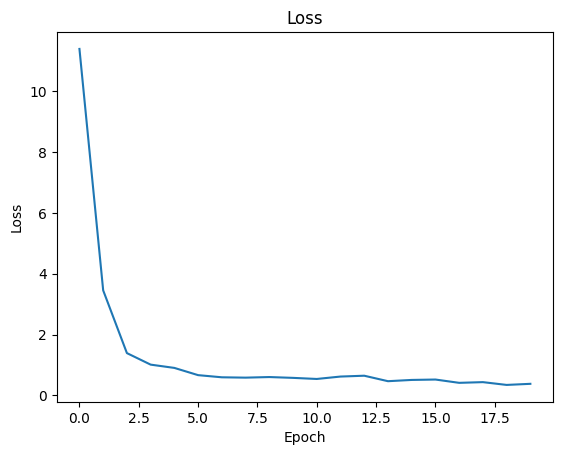

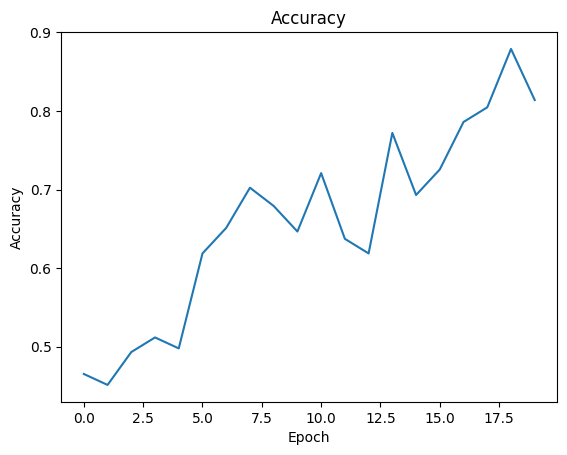

In [79]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.plot(history.history["accuracy"])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

A CNN model


In [85]:


base_path = "/content/homer_bart_1"

files = [
    f for f in os.listdir(base_path)
    if f.endswith(".bmp") and not f.startswith("._")
]

images = []
labels = []

for f in files:
    img = cv2.imread(os.path.join(base_path, f))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, (128,128))
    img = img.reshape(128, 128, 1)

    images.append(img)

    if "bart" in f.lower():
        labels.append(0)
    else:
        labels.append(1)

X = np.array(images) / 255.0
y = np.array(labels)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(X_train, y_train, epochs=10)
model.summary()

loss, acc = model.evaluate(X_test, y_test)
print("Test accuracy:", acc)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 637ms/step - accuracy: 0.4512 - loss: 1.2779
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 608ms/step - accuracy: 0.6047 - loss: 0.6497
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 824ms/step - accuracy: 0.6419 - loss: 0.5973
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 598ms/step - accuracy: 0.7721 - loss: 0.4839
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 613ms/step - accuracy: 0.8791 - loss: 0.3649
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 718ms/step - accuracy: 0.9023 - loss: 0.2562
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 775ms/step - accuracy: 0.9535 - loss: 0.1643
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 598ms/step - accuracy: 0.9721 - loss: 0.1149
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 610ms/step - accuracy: 1.0000 - loss: 0.0577
Epoch 10/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 824ms/step - accuracy: 1.0000 - loss: 0.0311


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,175,621 (84.59 MB)

 Trainable params: 7,391,873 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 14,783,748 (56.40 MB)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.7963 - loss: 0.4349
Test accuracy: 0.7962962985038757


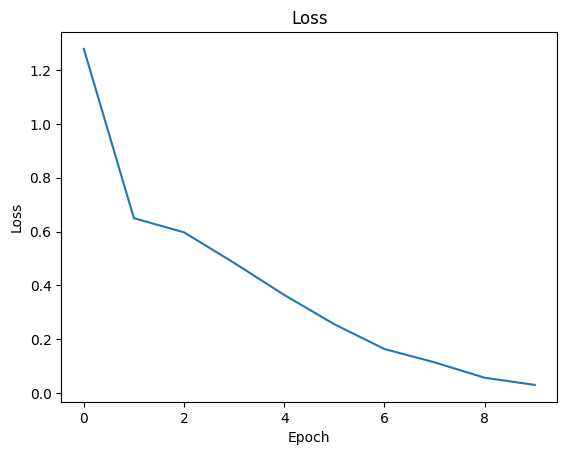

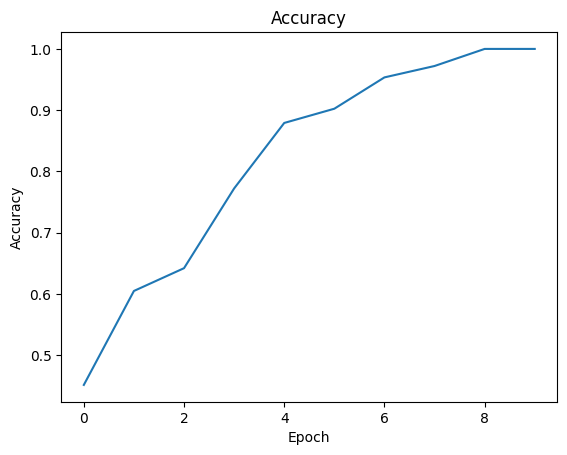

In [86]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.plot(history.history["accuracy"])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()